# 1.Data Preparation

## 1. Data Preparation

we used the Flickr8k dataset, which contains images along with multiple captions describing each image.

Each image has five different captions. This is useful because it shows that the same image can be described in different ways, helping the model learn more flexible language patterns.

Before using the captions, we cleaned them by:
- converting all text to lowercase
- removing punctuation and special characters
- splitting sentences into individual words (tokenization)

We then built a vocabulary from the most common words and added special tokens like:
- `<SOS>` (start of sentence)
- `<EOS>` (end of sentence)
- `<PAD>` (for padding)
- `<UNK>` (for unknown words)

Finally, each caption was converted into a sequence of numbers and padded to a fixed length so it can be processed by the model.

In [1]:
from datasets import load_dataset
import re
from collections import Counter
import random

dataset = load_dataset("jxie/flickr8k")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/train-00001-of-00002-2173151d8cd6c7(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/validation-00000-of-00001-7025a2b59(…):   0%|          | 0.00/138M [00:00<?, ?B/s]

data/test-00000-of-00001-42a2661d12c73e4(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [2]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 6000
    })
    validation: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
})


In [3]:
train=dataset["train"]
val=dataset["validation"]
test=dataset["test"]

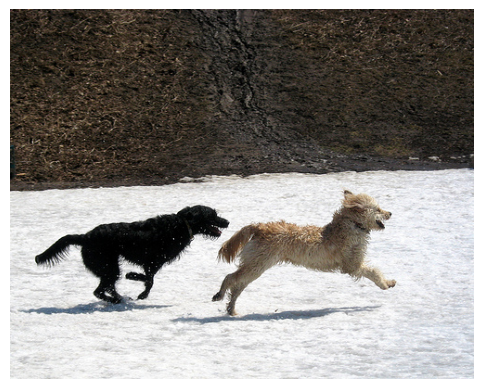


Captions:

1. A black dog is running after a white dog in the snow .
2. Black dog chasing brown dog through snow
3. Two dogs chase each other across the snowy ground .
4. Two dogs play together in the snow .
5. Two dogs running through a low lying body of water .


In [4]:
import matplotlib.pyplot as plt

sample = train[0]

# show image
plt.imshow(sample["image"])
plt.axis("off")
plt.show()

# show captions
print("\nCaptions:\n")
for i in range(5):
    print(f"{i+1}. {sample[f'caption_{i}']}")

# Caption Preprocessing

In [5]:
def clean_caption(caption):
    if caption is None:
        return ""

    caption = caption.lower().strip()
    caption = re.sub(r"[^a-z\s]", "", caption)
    return caption

# Tokenization

In [6]:
def tokenize(caption):
  return caption.split()

# Build Vocabulary

In [7]:
def build_vocab(dataset, max_size=10000):
    counter = Counter()

    for sample in dataset:
        for i in range(5):
            caption = sample.get(f"caption_{i}", None)

            caption = clean_caption(caption)
            if not caption:
                continue

            tokens = tokenize(caption)
            counter.update(tokens)

    vocab = [word for word, x in counter.most_common(max_size - 4)]

    vocab = ["<PAD>", "<UNK>", "<SOS>", "<EOS>"] + vocab

    word2idx = {word: idx for idx, word in enumerate(vocab)}
    idx2word = {idx: word for word, idx in word2idx.items()}

    return word2idx, idx2word

In [8]:
word2idx, idx2word = build_vocab(train)
print("Vocab size:", len(word2idx))


Vocab size: 7594


# Convert Captions to Sequences

In [13]:
img, seq = train_data[0]

print(seq)
print([idx2word[i] for i in seq])

[2, 4, 16, 10, 8, 33, 255, 4, 15, 10, 5, 6, 43, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
['<SOS>', 'a', 'black', 'dog', 'is', 'running', 'after', 'a', 'white', 'dog', 'in', 'the', 'snow', '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']


In [10]:
def encode_caption(caption, word2idx):
    caption = clean_caption(caption)
    tokens = tokenize(caption)

    seq = [word2idx.get(word, word2idx["<UNK>"]) for word in tokens]

    seq = [word2idx["<SOS>"]] + seq + [word2idx["<EOS>"]]

    return seq

# Pad Sequences

In [11]:
def pad_sequence(seq, max_len, pad_idx):
    if len(seq) < max_len:
        seq += [pad_idx] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq


# Apply to Dataset

In [12]:
def process_dataset(dataset, word2idx):
    processed = []

    for sample in dataset:
        img = sample["image"]

        for i in range(5):
            caption = sample[f"caption_{i}"]

            seq = encode_caption(caption, word2idx)
            seq = pad_sequence(seq, 30, word2idx["<PAD>"])

            processed.append((img, seq))

    return processed


train_data = process_dataset(train, word2idx)
val_data = process_dataset(val, word2idx)
test_data = process_dataset(test, word2idx)

print("Train samples:", len(train_data))

Train samples: 30000


#  2.ViT Encoder Feature Extraction

## 2. Vision Transformer Encoder

To extract features from images, we used a pre-trained Vision Transformer (ViT).

Instead of processing the image as a whole, ViT splits it into small patches (like a grid). Each patch is treated as a token, similar to words in a sentence.

We explored two different ways of using these features:

### CLS Token
The CLS token is a single vector that summarizes the entire image. It is simple and efficient, but it may miss some fine details.

### Patch Tokens
Here, we use all the patches instead of just one summary. This keeps spatial information, allowing the model to understand *where* things are in the image.

We also used a projection layer to match the feature size required by the decoder.

The ViT model was kept frozen during training to save time and computation.

In [14]:
from transformers import ViTModel, ViTImageProcessor
import torch
import torch.nn as nn

In [15]:
import torch
from transformers import ViTModel, ViTImageProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"

vit = ViTModel.from_pretrained("google/vit-base-patch16-224").to(device)
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")

# freeze ViT
for param in vit.parameters():
    param.requires_grad = False

vit.eval()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

ViTModel(
  (embeddings): ViTEmbeddings(
    (patch_embeddings): ViTPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ViTEncoder(
    (layer): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (attention): ViTSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): ViTSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ViTIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): ViTOutput(
          (d

In [16]:
from torchvision import transforms

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [17]:
import torch.nn as nn


d_model = 512
projection = nn.Linear(768, d_model).to(device)

### Strategy A–Patch tokens

In [18]:
def extract_patch_tokens(image):
    image = image_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = vit(pixel_values=image)
        hidden = outputs.last_hidden_state  # [1, 197, 768]

    patches = hidden[:, 1:, :]  # remove CLS → [1, 196, 768]

    patches = projection(patches)  # [1, 196, 512]

    return patches.squeeze(0)  # [196, 512]

In [19]:
features = extract_patch_tokens(img)
print(features.shape)

torch.Size([196, 512])


### Strategy B–CLS token

In [20]:
def extract_cls_token(image):
    image = image_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = vit(pixel_values=image)
        hidden = outputs.last_hidden_state  # [1, 197, 768]

    cls = hidden[:, 0, :]  # [1, 768]

    cls = projection(cls)  # [1, 512]

    return cls

In [21]:
features = extract_cls_token(img)
print(features.shape)

torch.Size([1, 512])


# 3.Transformer Decoder

## 3. Transformer Decoder

The decoder is responsible for generating captions one word at a time.

It takes:
- the image features from the encoder
- the previously generated words

and predicts the next word in the sentence.

The decoder uses:
- an embedding layer to represent words
- positional encoding to understand word order
- attention mechanisms to connect words with image features

A masking technique is used to ensure the model only looks at previous words when predicting the next one.

This setup allows the model to gradually build a full sentence.

In [22]:
import torch
import torch.nn as nn

class CaptionDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=512, n_heads=8, num_layers=2):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = nn.Parameter(torch.randn(1, 100, d_model))
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dropout=0.3,
            batch_first=True
        )

        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, tgt, memory):
        # tgt: [B, T]
        # memory: [B, N, 512]

        tgt_emb = self.embedding(tgt) + self.pos_encoding[:, :tgt.size(1), :]

        T = tgt.size(1)
        tgt_mask = torch.triu(torch.ones(T, T), diagonal=1).bool().to(tgt.device)

        out = self.decoder(
            tgt_emb,
            memory,
            tgt_mask=tgt_mask
        )

        return self.fc_out(out)

In [23]:
model = CaptionDecoder(len(word2idx)).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=word2idx["<PAD>"])
optimizer = torch.optim.Adam(model.parameters(),lr=5e-5)

In [24]:
def create_inputs_targets(seq):
    seq = torch.tensor(seq)

    input_seq = seq[:-1]
    target_seq = seq[1:]

    return input_seq, target_seq

In [25]:
img, seq = train_data[0]

input_seq, target_seq = create_inputs_targets(seq)

input_seq = input_seq.unsqueeze(0).to(device)   # [1, T]
target_seq = target_seq.unsqueeze(0).to(device)

memory = extract_patch_tokens(img).unsqueeze(0)  # [1, 196, 512]

outputs = model(input_seq, memory)

print("Output shape:", outputs.shape)

Output shape: torch.Size([1, 29, 7594])


#  4.Model Training and Evaluation

## 4. Model Training

We trained two separate models:
- one using the CLS token
- one using patch tokens

For training:
- captions were split into input and target sequences
- the model predicts the next word at each step
- we used cross-entropy loss to measure errors

We ignored padding tokens during training so they don’t affect the results.

As training progressed, the loss decreased, which indicates that the model was learning successfully.

In [26]:
model_cls = CaptionDecoder(len(word2idx)).to(device)
model_patch = CaptionDecoder(len(word2idx)).to(device)

optimizer_cls = torch.optim.Adam(model_cls.parameters(), lr=5e-5)
optimizer_patch = torch.optim.Adam(model_patch.parameters(), lr=5e-5)

criterion = nn.CrossEntropyLoss(ignore_index=word2idx["<PAD>"])

In [27]:
def train_step_model(model, optimizer, img, seq, strategy="patch"):
    model.train()

    input_seq, target_seq = create_inputs_targets(seq)

    input_seq = input_seq.unsqueeze(0).to(device)
    target_seq = target_seq.unsqueeze(0).to(device)

    if strategy == "patch":
        memory = extract_patch_tokens(img).unsqueeze(0)
    else:
        memory = extract_cls_token(img).unsqueeze(0)

    outputs = model(input_seq, memory)

    loss = criterion(
        outputs.view(-1, outputs.size(-1)),
        target_seq.view(-1)
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

In [28]:
def evaluate_model(model, data, strategy, num_samples=200):
    model.eval()
    total = 0

    with torch.no_grad():
        for img, seq in data[:num_samples]:
            inp, tgt = create_inputs_targets(seq)
            inp = inp.unsqueeze(0).to(device)
            tgt = tgt.unsqueeze(0).to(device)

            memory = extract_patch_tokens(img) if strategy=="patch" else extract_cls_token(img)
            memory = memory.unsqueeze(0)

            out = model(inp, memory)

            loss = criterion(out.view(-1, out.size(-1)), tgt.view(-1))
            total += loss.item()

    return total / num_samples

In [29]:
EPOCHS = 5

for epoch in range(EPOCHS):
    total_loss = 0

    for img, seq in train_data[:2000]:
        loss = train_step_model(
            model_cls,
            optimizer_cls,
            img,
            seq,
            strategy="cls"
        )
        total_loss += loss

    train_loss = total_loss / 1000

    val_loss = evaluate_model(model_cls, val_data, "cls")

    print(f"[CLS] Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

[CLS] Epoch 1 | Train: 10.2635 | Val: 4.4496
[CLS] Epoch 2 | Train: 7.9060 | Val: 4.2425
[CLS] Epoch 3 | Train: 6.9652 | Val: 4.1603
[CLS] Epoch 4 | Train: 6.2383 | Val: 4.1186
[CLS] Epoch 5 | Train: 5.6384 | Val: 4.1320


In [30]:
for epoch in range(EPOCHS):
    total_loss = 0
    for img, seq in train_data[:2000]:
        loss = train_step_model(
            model_patch,
            optimizer_patch,
            img,
            seq,
            strategy="patch"
        )
        total_loss += loss

    train_loss = total_loss / 1000
    val_loss = evaluate_model(model_patch, val_data, "patch")

    print(f"[PATCH] Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

[PATCH] Epoch 1 | Train: 10.1857 | Val: 4.4421
[PATCH] Epoch 2 | Train: 7.8382 | Val: 4.2200
[PATCH] Epoch 3 | Train: 6.8589 | Val: 4.1551
[PATCH] Epoch 4 | Train: 6.1055 | Val: 4.1221
[PATCH] Epoch 5 | Train: 5.4720 | Val: 4.1392


## 5. Caption Generation

After training, we tested the model by generating captions for new images.

We used a simple greedy decoding approach:
- start with `<SOS>`
- predict the next word
- keep adding words until `<EOS>` is generated

This allows the model to generate full sentences without using ground-truth captions.

We compared the captions produced by both models to see the difference.

In [32]:
def generate_caption_model(model, img, strategy="patch", max_len=30):
    model.eval()

    if strategy == "patch":
        memory = extract_patch_tokens(img).unsqueeze(0)
    else:
        memory = extract_cls_token(img).unsqueeze(0)

    seq = [word2idx["<SOS>"]]

    for i in range(max_len):
        input_seq = torch.tensor(seq).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(input_seq, memory)

        next_token = outputs[0, -1].argmax().item()
        seq.append(next_token)

        if next_token == word2idx["<EOS>"]:
            break

    return " ".join([idx2word[i] for i in seq])

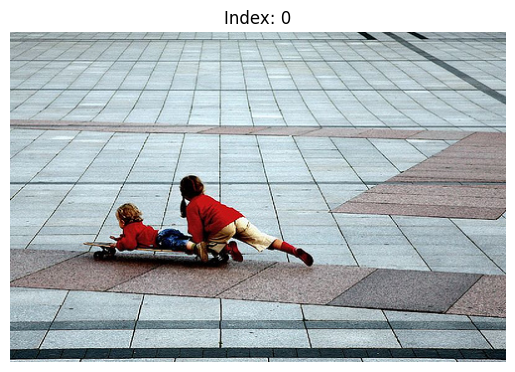


Reference captions:

1. the boy laying face down on a skateboard is being pushed along the ground by another boy .
2. Two girls play on a skateboard in a courtyard .
3. Two people play on a long skateboard .
4. Two small children in red shirts playing on a skateboard .
5. two young children on a skateboard going across a sidewalk

CLS caption: <SOS> a young boy wearing a red shirt and white jacket is sitting on a red shirt and a red and white man walking down <EOS>
PATCH caption: <SOS> a young child wearing a red jacket is sitting on a red hat <EOS>


In [33]:

sample = val[0]

img = sample["image"]
refs = [sample[f"caption_{i}"] for i in range(5)]

# 1. show image
plt.imshow(img)
plt.axis("off")
plt.title(f"Index: {0}")
plt.show()

# 2. show ground truth captions
print("\nReference captions:\n")
for i, r in enumerate(refs):
    print(f"{i+1}. {r}")

# 3. generate captions
print("\nCLS caption:", generate_caption_model(model_cls, img, "cls"))
print("PATCH caption:", generate_caption_model(model_patch, img, "patch"))

## 6. BLEU Evaluation

To evaluate the captions, we used BLEU scores, which measure how similar the generated caption is to the reference captions.

We computed:
- BLEU-1 (single words)
- BLEU-2 (pairs of words)
- BLEU-3 and BLEU-4 (longer sequences)

We applied smoothing to avoid zero scores when exact matches are rare.


In [34]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def compute_bleu(model, img, refs, strategy):
    pred = generate_caption_model(model, img, strategy)
    pred_tokens = pred.split()

    references = [clean_caption(r).split() for r in refs]

    smooth = SmoothingFunction().method1

    bleu1 = sentence_bleu(
        references, pred_tokens,
        weights=(1, 0, 0, 0),
        smoothing_function=smooth
    )

    bleu2 = sentence_bleu(
        references, pred_tokens,
        weights=(0.5, 0.5, 0, 0),
        smoothing_function=smooth
    )

    bleu3 = sentence_bleu(
        references, pred_tokens,
        weights=(0.33, 0.33, 0.33, 0),
        smoothing_function=smooth
    )

    bleu4 = sentence_bleu(
        references, pred_tokens,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )

    return bleu1, bleu2, bleu3, bleu4

In [35]:
sample = val[0]

img = sample["image"]
refs = [sample[f"caption_{i}"] for i in range(5)]

print("CLS:", compute_bleu(model_cls,img, refs, "cls"))
print("PATCH:", compute_bleu(model_patch,img, refs, "patch"))

CLS: (0.30769230769230765, 0.11094003924504585, 0.03839622944668605, 0.021729983079834318)
PATCH: (0.350069327617179, 0.1479312908428049, 0.0543188176542257, 0.032195554434125126)


# 5. Attention Visualization

## 5. Attention Visualization

To better understand what the model is focusing on, we visualized attention maps from the Vision Transformer.

We extracted attention values and mapped them back to image regions.

These maps were displayed as heatmaps over the original images:
- warm colors (red/yellow) show important regions
- cool colors (blue) show less important areas

We noticed that the model focuses on meaningful parts of the image, such as objects or actions.

At first, the heatmaps appeared blocky due to patch-based representation, but we applied smoothing to make them clearer and easier to interpret.

In [36]:
from transformers import ViTModel

vit_attn = ViTModel.from_pretrained(
    "google/vit-base-patch16-224",
    output_attentions=True
).to(device)

vit_attn.eval()

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ViTModel(
  (embeddings): ViTEmbeddings(
    (patch_embeddings): ViTPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ViTEncoder(
    (layer): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (attention): ViTSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): ViTSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ViTIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): ViTOutput(
          (d

In [39]:
def get_attention_map(image):
    image = image_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = vit_attn(pixel_values=image)

    attentions = outputs.attentions  # list of layers

    last_layer = attentions[-1]  # [1, heads, 197, 197]

    # CLS → patches
    cls_attention = last_layer[0, :, 0, 1:]  # [heads, 196]

    # average heads
    cls_attention = cls_attention.mean(0)  # [196]

    return cls_attention

In [40]:
import matplotlib.pyplot as plt
import numpy as np

import cv2

def show_attention(image):
    image_resized = image.resize((224, 224))

    attn = get_attention_map(image).cpu().numpy()
    attn = attn.reshape(14, 14)

    attn = cv2.resize(attn, (224, 224))

    plt.figure(figsize=(5,5))
    plt.imshow(image_resized)
    plt.imshow(attn, cmap='jet', alpha=0.4)
    plt.axis("off")
    plt.show()


Example 1
CLS: <SOS> a young boy wearing a red shirt and white jacket is sitting on a red shirt and a red and white man walking down <EOS>
PATCH: <SOS> a young child wearing a red jacket is sitting on a red hat <EOS>


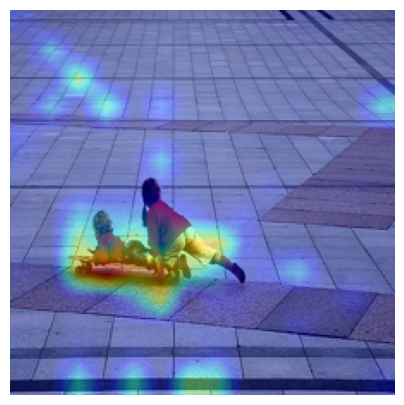


Example 2
CLS: <SOS> a girl is jumping in the grass <EOS>
PATCH: <SOS> a girl is jumping in the air on a green toy in the air <EOS>


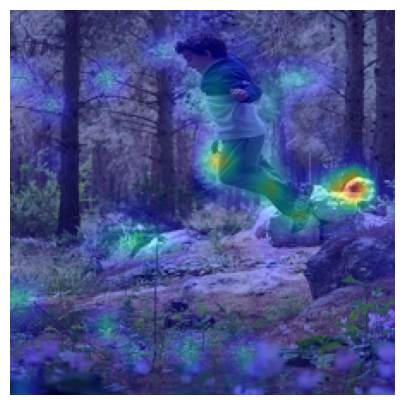


Example 3
CLS: <SOS> a girl is jumping through the snow <EOS>
PATCH: <SOS> a small white dog is jumping through a green green toy <EOS>


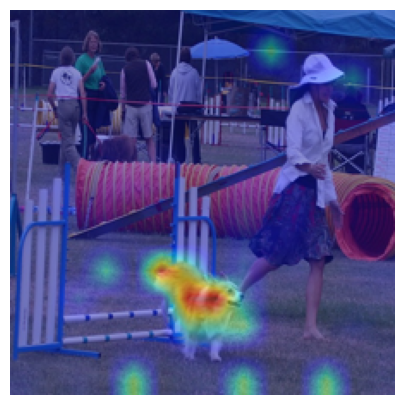


Example 4
CLS: <SOS> a man is standing on a field <EOS>
PATCH: <SOS> a man is jumping in the grass <EOS>


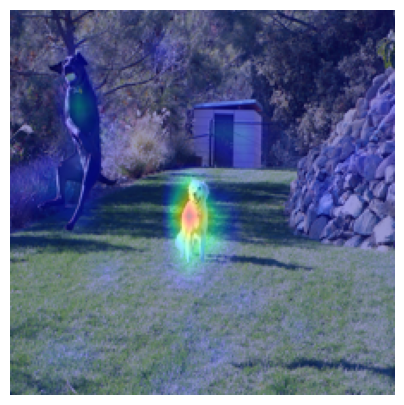


Example 5
CLS: <SOS> a man is jumping in the water <EOS>
PATCH: <SOS> two children are standing on a beach <EOS>


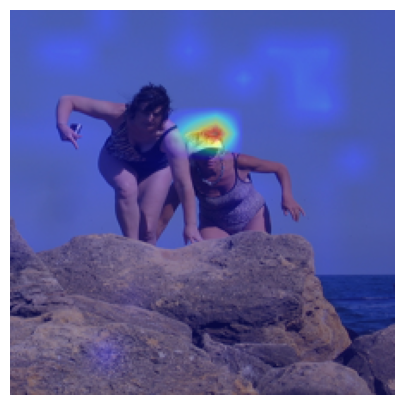

In [41]:
for i in range(5):
    sample = val[i]

    img = sample["image"]

    print(f"\nExample {i+1}")

    print("CLS:", generate_caption_model(model_cls, img, "cls"))
    print("PATCH:", generate_caption_model(model_patch, img, "patch"))

    show_attention(img)

In [42]:
def evaluate_on_test(model, data, strategy):
    scores = []

    for sample in test:
        img = sample["image"]
        refs = [sample[f"caption_{i}"] for i in range(5)]

        scores.append(compute_bleu(model, img, refs, strategy))

    return np.mean(scores, axis=0)


print("\nFINAL TEST RESULTS:")
print("CLS:", evaluate_on_test(model_cls, test, "cls"))
print("PATCH:", evaluate_on_test(model_patch, test, "patch"))


FINAL TEST RESULTS:
CLS: [0.43792515 0.26487427 0.14568898 0.08669175]
PATCH: [0.43405058 0.2621101  0.14526063 0.0862725 ]


## 8. Results and Comparison

We compared the CLS-based and patch-based models using both numbers (BLEU scores) and actual generated captions.

### Quantitative Results:
- CLS model achieved higher BLEU scores

### Qualitative Results:
- Patch model generated more detailed and natural captions
- It captured things like object count and scene context better

### Example:
- CLS: "a brown dog running through the snow"
- Patch: "two dogs are running through water"

Even though the BLEU score is lower, the patch-based caption is more informative and realistic.